PROJECT 4
Oklahoma and Washington Risk Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
## Load files from the folder
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")

ok_tract_data = pd.read_csv("NRI_Table_CensusTracts_Oklahoma.csv", low_memory=False)
wa_tract_data = pd.read_csv("NRI_Table_CensusTracts_Washington.csv", low_memory=False)

ok_county_data = pd.read_csv("NRI_Table_Counties_Oklahoma.csv", low_memory=False)
wa_county_data = pd.read_csv("NRI_Table_Counties_Washington.csv", low_memory=False)

nri_dictionary = pd.read_csv("NRIDataDictionary.csv", low_memory=False)

print("Shapefile loaded.")
print("Oklahoma tract file shape:", ok_tract_data.shape)
print("Washington tract file shape:", wa_tract_data.shape)

Shapefile loaded.
Oklahoma tract file shape: (1205, 158)
Washington tract file shape: (1772, 158)


In [5]:
## Clean Shapefile
tracts = tracts.replace(-9999, np.nan)

print("Original CRS:", tracts.crs)

if tracts.crs is None:
    tracts = tracts.set_crs(epsg=3857)

tracts = tracts.to_crs(epsg=4326)

print("New CRS:", tracts.crs)
tracts.head()

Original CRS: EPSG:3857
New CRS: EPSG:4326


,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((-86.47888 32.48935, -86.47904 32.488..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((-86.46732 32.48922, -86.46738 32.489..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((-86.45069 32.46035, -86.45087 32.460..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((-86.436 32.48023, -86.43596 32.48019..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((-86.41168 32.45981, -86.41168 32.456..."


In [7]:
## Celan seperate tracts head
ok_tract_data = ok_tract_data.replace(-9999, np.nan)
wa_tract_data = wa_tract_data.replace(-9999, np.nan)

ok_tract_data["STATE_SOURCE"] = "Oklahoma"
wa_tract_data["STATE_SOURCE"] = "Washington"

state_tract_data = pd.concat([ok_tract_data, wa_tract_data], ignore_index=True)

print(state_tract_data.shape)
state_tract_data.head()

(2977, 159)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,STATE_SOURCE
0,40,Oklahoma,OK,40001,Adair County,40001376600,Census Tract 3766; Adair County; Oklahoma,79.510754,2203,217,...,1.0,27.9,6.5,0.2,0.3,7.2,3.5,0.0,1.0,Oklahoma
1,40,Oklahoma,OK,40001,Adair County,40001376700,Census Tract 3767; Adair County; Oklahoma,139.564764,5127,473,...,1.4,26.5,4.4,0.0,0.4,10.0,3.6,0.0,0.4,Oklahoma
2,40,Oklahoma,OK,40001,Adair County,40001376800,Census Tract 3768; Adair County; Oklahoma,184.169979,4165,366,...,0.2,56.8,4.1,0.0,0.5,10.8,2.9,0.0,0.5,Oklahoma
3,40,Oklahoma,OK,40001,Adair County,40001376900,Census Tract 3769; Adair County; Oklahoma,15.380316,4113,160,...,0.3,47.9,5.2,0.0,0.5,9.3,3.4,0.0,0.5,Oklahoma
4,40,Oklahoma,OK,40001,Adair County,40001377000,Census Tract 3770; Adair County; Oklahoma,155.255177,4118,364,...,1.6,52.5,4.7,0.0,0.5,8.8,3.0,0.0,0.5,Oklahoma


In [8]:
## Filter shapefile to Oklahoma and Washington 
tracts_ok = tracts[tracts["STATE"] == "Oklahoma"].copy()
tracts_wa = tracts[tracts["STATE"] == "Washington"].copy()

tracts_two_states = pd.concat([tracts_ok, tracts_wa], ignore_index=True)

print(tracts_two_states["STATE"].value_counts())
print(tracts_two_states.shape)

STATE
Washington    1772
Oklahoma      1205
Name: count, dtype: int64
(2977, 469)


In [11]:
## Clean join columns
tracts_two_states["TRACTFIPS"] = (
    tracts_two_states["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(11)
)

state_tract_data["FIPS"] = (
    state_tract_data["FIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(11)
)

print(tracts_two_states["TRACTFIPS"].head())
print(state_tract_data["FIPS"].head())

0    40001376600
1    40001376700
2    40001376800
3    40001376900
4    40001377000
Name: TRACTFIPS, dtype: object
0    40001376600
1    40001376700
2    40001376800
3    40001376900
4    40001377000
Name: FIPS, dtype: object


In [12]:
## Merge NRI shapefile with SVI tract data
risk_data = tracts_two_states.merge(
    state_tract_data,
    left_on="TRACTFIPS",
    right_on="FIPS",
    how="left",
    suffixes=("_nri", "_svi")
)

print(risk_data.shape)
risk_data.head()

(2977, 628)


,NRI_ID,STATE_nri,STATEABBRV,STATEFIPS,COUNTY_nri,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,STATE_SOURCE
0,T40001376600,Oklahoma,OK,40,Adair,County,001,40001,376600,40001376600,...,1.0,27.9,6.5,0.2,0.3,7.2,3.5,0.0,1.0,Oklahoma
1,T40001376700,Oklahoma,OK,40,Adair,County,001,40001,376700,40001376700,...,1.4,26.5,4.4,0.0,0.4,10.0,3.6,0.0,0.4,Oklahoma
2,T40001376800,Oklahoma,OK,40,Adair,County,001,40001,376800,40001376800,...,0.2,56.8,4.1,0.0,0.5,10.8,2.9,0.0,0.5,Oklahoma
3,T40001376900,Oklahoma,OK,40,Adair,County,001,40001,376900,40001376900,...,0.3,47.9,5.2,0.0,0.5,9.3,3.4,0.0,0.5,Oklahoma
4,T40001377000,Oklahoma,OK,40,Adair,County,001,40001,377000,40001377000,...,1.6,52.5,4.7,0.0,0.5,8.8,3.0,0.0,0.5,Oklahoma


In [25]:
## Make one clean state column
if "STATE_nri" in risk_data.columns:
    risk_data["STATE"] = risk_data["STATE_nri"]
elif "STATE_x" in risk_data.columns:
    risk_data["STATE"] = risk_data["STATE_x"]
elif "STATE_shape" in risk_data.columns:
    risk_data["STATE"] = risk_data["STATE_shape"]

print([col for col in risk_data.columns if "STATE" in col])

['STATE_nri', 'STATEABBRV', 'STATEFIPS', 'STATE_svi', 'STATE_SOURCE', 'STATE']


In [22]:
## Main NRI columns from the shapefile
risk_score_col = "RISK_SCORE"
risk_spctl_col = "RISK_SPCTL"
eal_col = "EAL_VALT"
population_col = "POPULATION"

print("NRI score column:", risk_score_col)
print("NRI percentile column:", risk_spctl_col)
print("Impact column:", eal_col)
print("Population column:", population_col)

NRI score column: RISK_SCORE
NRI percentile column: RISK_SPCTL
Impact column: EAL_VALT
Population column: POPULATION


In [14]:
## Check Missing Values
missing_counts = risk_data.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

missing_counts.head(25)

ERQK_EVNTS    2977
WFIR_EVNTS    2977
CFLD_EVNTS    2977
AVLN_EALT     2879
AVLN_EALB     2879
AVLN_EALPE    2879
AVLN_EALS     2879
AVLN_EXPB     2879
AVLN_EVNTS    2879
AVLN_AFREQ    2879
AVLN_ALRB     2879
AVLN_EXP_A    2879
AVLN_ALRP     2879
AVLN_EXPP     2879
AVLN_EALP     2879
AVLN_EXPPE    2879
AVLN_RISKV    2879
AVLN_EXPT     2879
AVLN_RISKS    2879
AVLN_HLRB     2879
AVLN_HLRP     2879
AVLN_ALR_N    2879
HRCN_ALRB     1780
HRCN_ALRP     1780
HRCN_ALRA     1780
dtype: int64

In [39]:
## Helper functions
def min_max_scale(series):
    series = pd.to_numeric(series, errors="coerce")
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.nan, index=series.index)

    return (series - min_val) / (max_val - min_val)


def risk_rating_from_percentile(series):
    return pd.cut(
        pd.to_numeric(series, errors="coerce"),
        bins=[-0.01, 20, 40, 60, 80, 100],
        labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )


def first_column_that_exists(df, column_list):
    for col in column_list:
        if col in df.columns:
            return col
    return None

In [20]:
## Find the main comparison columns
risk_score_col = first_column_that_exists(risk_data, ["RISK_SCORE_shape", "RISK_SCORE_tract", "RISK_SCORE"])
risk_spctl_col = first_column_that_exists(risk_data, ["RISK_SPCTL_shape", "RISK_SPCTL_tract", "RISK_SPCTL"])
eal_col = first_column_that_exists(risk_data, ["EAL_VALT_shape", "EAL_VALT_tract", "EAL_VALT"])
population_col = first_column_that_exists(risk_data, ["POPULATION_shape", "POPULATION_tract", "POPULATION"])

print("NRI score column:", risk_score_col)
print("NRI percentile column:", risk_spctl_col)
print("Impact column:", eal_col)
print("Population column:", population_col)


NRI score column: None
NRI percentile column: None
Impact column: None
Population column: None


In [40]:
## Composite alternative risk
afreq_cols = [col for col in risk_data.columns if col.endswith("_AFREQ")]

risk_data["total_frequency"] = risk_data[afreq_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)
risk_data["scaled_total_frequency"] = min_max_scale(risk_data["total_frequency"])
risk_data["scaled_eal_total"] = min_max_scale(risk_data[eal_col])

risk_data["alt_risk_composite"] = risk_data["scaled_total_frequency"] * risk_data["scaled_eal_total"]
risk_data["alt_risk_composite_pct"] = risk_data["alt_risk_composite"].rank(pct=True) * 100
risk_data["alt_risk_composite_rating"] = risk_rating_from_percentile(risk_data["alt_risk_composite_pct"])

risk_data[[
    "STATE",
    "TRACTFIPS",
    eal_col,
    "total_frequency",
    "alt_risk_composite",
    "alt_risk_composite_pct",
    "alt_risk_composite_rating"
]].head()

,STATE,TRACTFIPS,EAL_VALT,total_frequency,alt_risk_composite,alt_risk_composite_pct,alt_risk_composite_rating
0,Oklahoma,40001376600,8.973094e+05,120.914997,0.020514,83.103796,Very High
1,Oklahoma,40001376700,1.631193e+06,126.018140,0.039141,97.010413,Very High
2,Oklahoma,40001376800,1.251305e+06,138.139342,0.032874,94.625462,Very High
3,Oklahoma,40001376900,1.241647e+06,143.265279,0.033843,94.894189,Very High
4,Oklahoma,40001377000,1.441900e+06,139.864462,0.038413,96.741686,Very High


In [28]:
## Per-capita alternative risk
risk_data["population_clean"] = pd.to_numeric(risk_data[population_col], errors="coerce")
risk_data.loc[risk_data["population_clean"] == 0, "population_clean"] = np.nan

risk_data["alt_risk_per_capita"] = risk_data["alt_risk_composite"] / risk_data["population_clean"]
risk_data["alt_risk_per_capita_pct"] = risk_data["alt_risk_per_capita"].rank(pct=True) * 100
risk_data["alt_risk_per_capita_rating"] = risk_rating_from_percentile(risk_data["alt_risk_per_capita_pct"])

risk_data[[
    "STATE",
    "TRACTFIPS",
    "population_clean",
    "alt_risk_per_capita",
    "alt_risk_per_capita_pct",
    "alt_risk_per_capita_rating"
]].head()


,STATE,TRACTFIPS,population_clean,alt_risk_per_capita,alt_risk_per_capita_pct,alt_risk_per_capita_rating
0,Oklahoma,40001376600,2305.0,NaN,NaN,NaN
1,Oklahoma,40001376700,4647.0,NaN,NaN,NaN
2,Oklahoma,40001376800,3839.0,NaN,NaN,NaN
3,Oklahoma,40001376900,4305.0,NaN,NaN,NaN
4,Oklahoma,40001377000,4349.0,NaN,NaN,NaN


In [29]:
## Find hazard-specific columns
ok_tornado_freq = first_column_that_exists(risk_data, ["TRND_AFREQ", "TORN_AFREQ"])
ok_tornado_impact = first_column_that_exists(risk_data, ["TRND_EALT", "TORN_EALT"])

wa_eq_freq = first_column_that_exists(risk_data, ["ERQK_AFREQ"])
wa_eq_impact = first_column_that_exists(risk_data, ["ERQK_EALT"])

wa_fire_freq = first_column_that_exists(risk_data, ["WFIR_AFREQ", "WILD_AFREQ"])
wa_fire_impact = first_column_that_exists(risk_data, ["WFIR_EALT", "WILD_EALT"])

print("Oklahoma tornado columns:", ok_tornado_freq, ok_tornado_impact)
print("Washington earthquake columns:", wa_eq_freq, wa_eq_impact)
print("Washington wildfire columns:", wa_fire_freq, wa_fire_impact)

Oklahoma tornado columns: TRND_AFREQ TRND_EALT
Washington earthquake columns: ERQK_AFREQ ERQK_EALT
Washington wildfire columns: WFIR_AFREQ WFIR_EALT


In [45]:
## Oklahoma tornado alternative risk
risk_data["ok_tornado_freq_scaled"] = min_max_scale(risk_data["TRND_AFREQ"])
risk_data["ok_tornado_impact_scaled"] = min_max_scale(risk_data["TRND_EALT"])
risk_data["ok_tornado_alt_risk"] = (
    risk_data["ok_tornado_freq_scaled"] * risk_data["ok_tornado_impact_scaled"]
)
risk_data["ok_tornado_alt_risk_pct"] = risk_data["ok_tornado_alt_risk"].rank(pct=True) * 100

In [46]:
## Washington earthquake alternative risk
risk_data["wa_earthquake_freq_scaled"] = min_max_scale(risk_data["ERQK_AFREQ"])
risk_data["wa_earthquake_impact_scaled"] = min_max_scale(risk_data["ERQK_EALT"])
risk_data["wa_earthquake_alt_risk"] = (
    risk_data["wa_earthquake_freq_scaled"] * risk_data["wa_earthquake_impact_scaled"]
)
risk_data["wa_earthquake_alt_risk_pct"] = risk_data["wa_earthquake_alt_risk"].rank(pct=True) * 100

In [47]:
## Washington wildfire alternative risk
risk_data["wa_wildfire_freq_scaled"] = min_max_scale(risk_data["WFIR_AFREQ"])
risk_data["wa_wildfire_impact_scaled"] = min_max_scale(risk_data["WFIR_EALT"])
risk_data["wa_wildfire_alt_risk"] = (
    risk_data["wa_wildfire_freq_scaled"] * risk_data["wa_wildfire_impact_scaled"]
)
risk_data["wa_wildfire_alt_risk_pct"] = risk_data["wa_wildfire_alt_risk"].rank(pct=True) * 100

In [48]:
## Summary Table 1: State-level comparison of the NRI and proposed risk

summary_table_1 = risk_data.groupby("STATE").agg(
    mean_nri_risk_score=(risk_score_col, "mean"),
    mean_nri_percentile=(risk_spctl_col, "mean"),
    mean_alt_composite=("alt_risk_composite", "mean"),
    mean_alt_composite_pct=("alt_risk_composite_pct", "mean"),
    median_alt_composite=("alt_risk_composite", "median"),
    tract_count=("TRACTFIPS", "count")
).round(4)

summary_table_1

,mean_nri_risk_score,mean_nri_percentile,mean_alt_composite,mean_alt_composite_pct,median_alt_composite,tract_count
STATE,,,,,,
Oklahoma,62.5189,50.0415,0.0206,79.1156,0.0184,1205
Washington,65.2345,50.0282,0.0016,30.2290,0.0008,1772


In [49]:
## Summary Table 2: Category comparison between NRI and proposed risk
risk_data["nri_rating_from_percentile"] = risk_rating_from_percentile(risk_data[risk_spctl_col])

summary_table_2 = pd.crosstab(
    risk_data["nri_rating_from_percentile"],
    risk_data["alt_risk_composite_rating"],
    dropna=False
)

summary_table_2


alt_risk_composite_rating,Very Low,Low,Moderate,High,Very High
nri_rating_from_percentile,,,,,
Very Low,219,88,118,167,3
Low,189,102,64,207,33
Moderate,126,146,83,130,111
High,48,167,139,41,200
Very High,13,92,192,50,249


In [51]:
## Summary Table 3: Hazard-specific alternative risk comparison

hazard_rows = []

ok_only = risk_data[risk_data["STATE"] == "Oklahoma"]
wa_only = risk_data[risk_data["STATE"] == "Washington"]

hazard_rows.append({
    "State": "Oklahoma",
    "Hazard": "Tornado",
    "Mean_Alternative_Risk": ok_only["ok_tornado_alt_risk"].mean(),
    "Median_Alternative_Risk": ok_only["ok_tornado_alt_risk"].median(),
    "Max_Alternative_Risk": ok_only["ok_tornado_alt_risk"].max()
})

hazard_rows.append({
    "State": "Washington",
    "Hazard": "Earthquake",
    "Mean_Alternative_Risk": wa_only["wa_earthquake_alt_risk"].mean(),
    "Median_Alternative_Risk": wa_only["wa_earthquake_alt_risk"].median(),
    "Max_Alternative_Risk": wa_only["wa_earthquake_alt_risk"].max()
})

hazard_rows.append({
    "State": "Washington",
    "Hazard": "Wildfire",
    "Mean_Alternative_Risk": wa_only["wa_wildfire_alt_risk"].mean(),
    "Median_Alternative_Risk": wa_only["wa_wildfire_alt_risk"].median(),
    "Max_Alternative_Risk": wa_only["wa_wildfire_alt_risk"].max()
})

summary_table_3 = pd.DataFrame(hazard_rows).round(4)
summary_table_3

,State,Hazard,Mean_Alternative_Risk,Median_Alternative_Risk,Max_Alternative_Risk
0,Oklahoma,Tornado,0.0122,0.0009,0.3149
1,Washington,Earthquake,0.0012,0.0008,0.0354
2,Washington,Wildfire,0.0046,0.0000,0.7601


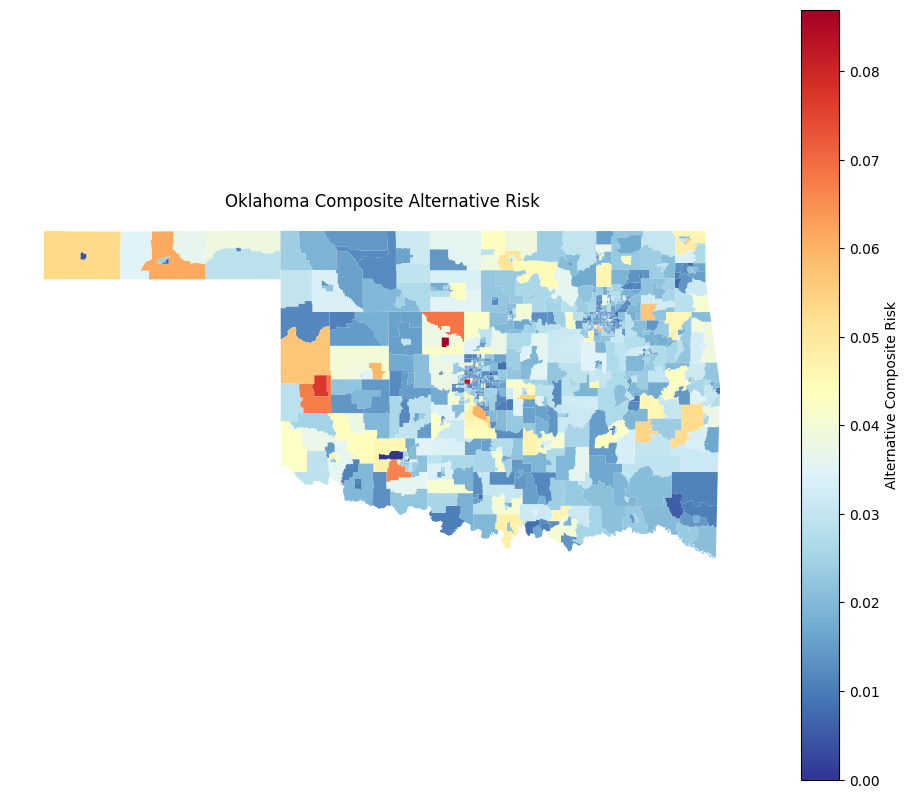

In [53]:
## Oklahoma composite alternative risk map
ok_map = risk_data[risk_data["STATE"] == "Oklahoma"].copy()
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ok_map.plot(
    column="alt_risk_composite",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Alternative Composite Risk"}
)
ax.set_title("Oklahoma Composite Alternative Risk")
ax.axis("off")
plt.show()

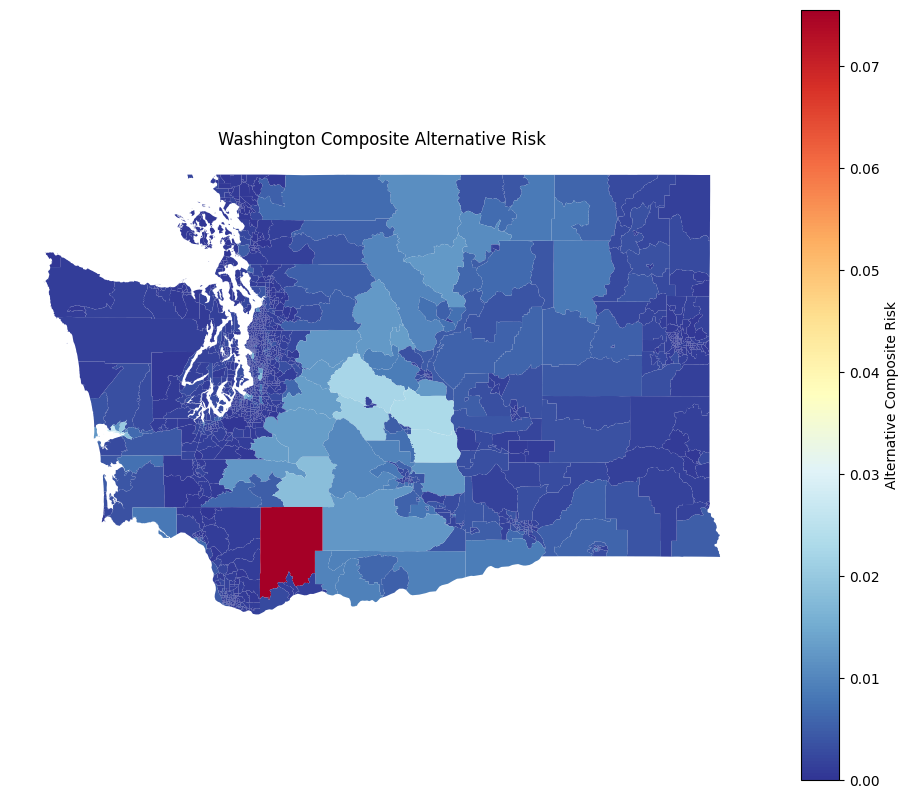

In [55]:
# Washington composite alternative risk map
wa_map = risk_data[risk_data["STATE"] == "Washington"].copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
wa_map.plot(
    column="alt_risk_composite",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=ax,
    legend=True, 
    legend_kwds={"label": "Alternative Composite Risk"}
)
ax.set_title("Washington Composite Alternative Risk")
ax.axis("off")
plt.show()

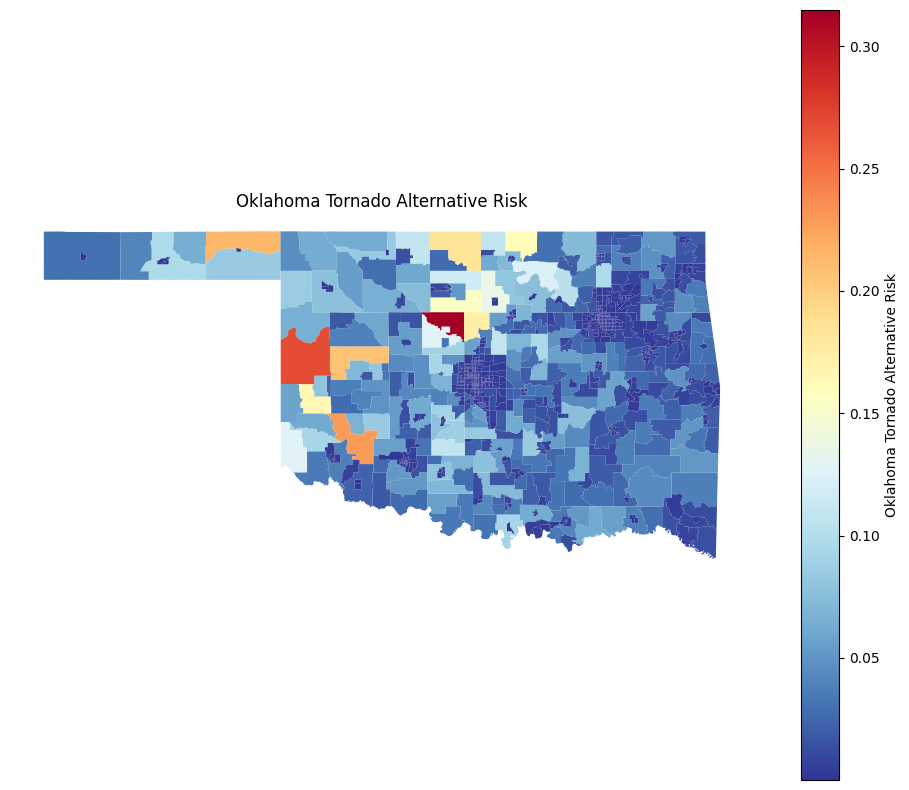

In [56]:
## Oklahoma tornado alternative risk map
if "ok_tornado_alt_risk" in risk_data.columns:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ok_map.plot(
    column="ok_tornado_alt_risk",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Oklahoma Tornado Alternative Risk"}
    )
    ax.set_title("Oklahoma Tornado Alternative Risk")
    ax.axis("off")
    plt.show()

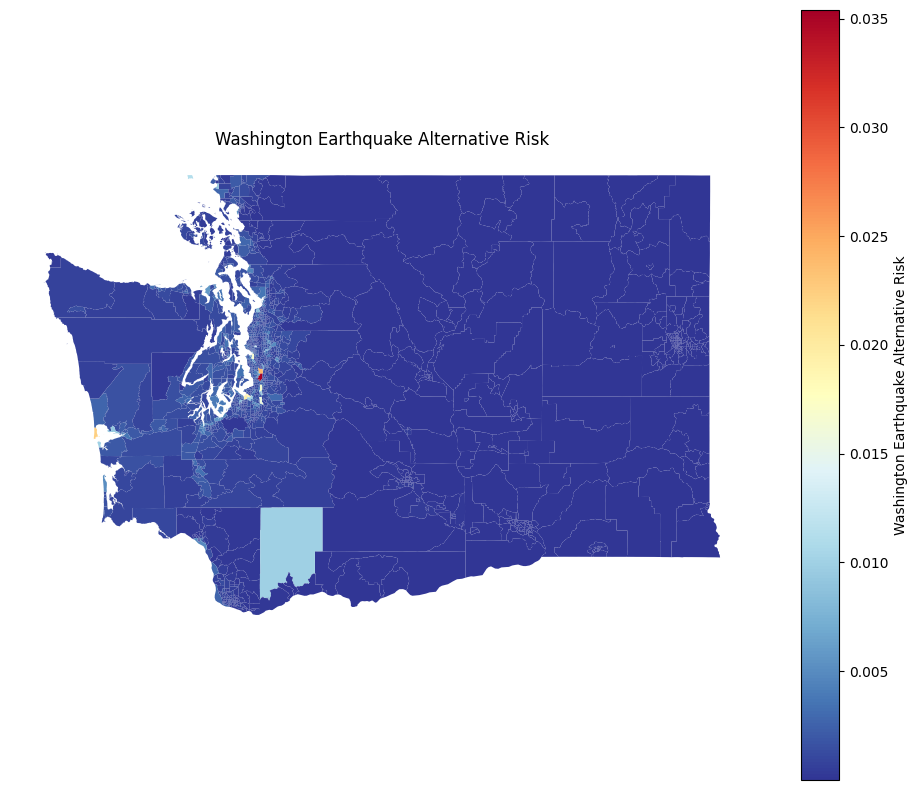

In [57]:
## Washington earthquake alternative risk map
if "wa_earthquake_alt_risk" in risk_data.columns:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    wa_map.plot(
    column="wa_earthquake_alt_risk",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Washington Earthquake Alternative Risk"}
    )
    ax.set_title("Washington Earthquake Alternative Risk")
    ax.axis("off")
    plt.show()

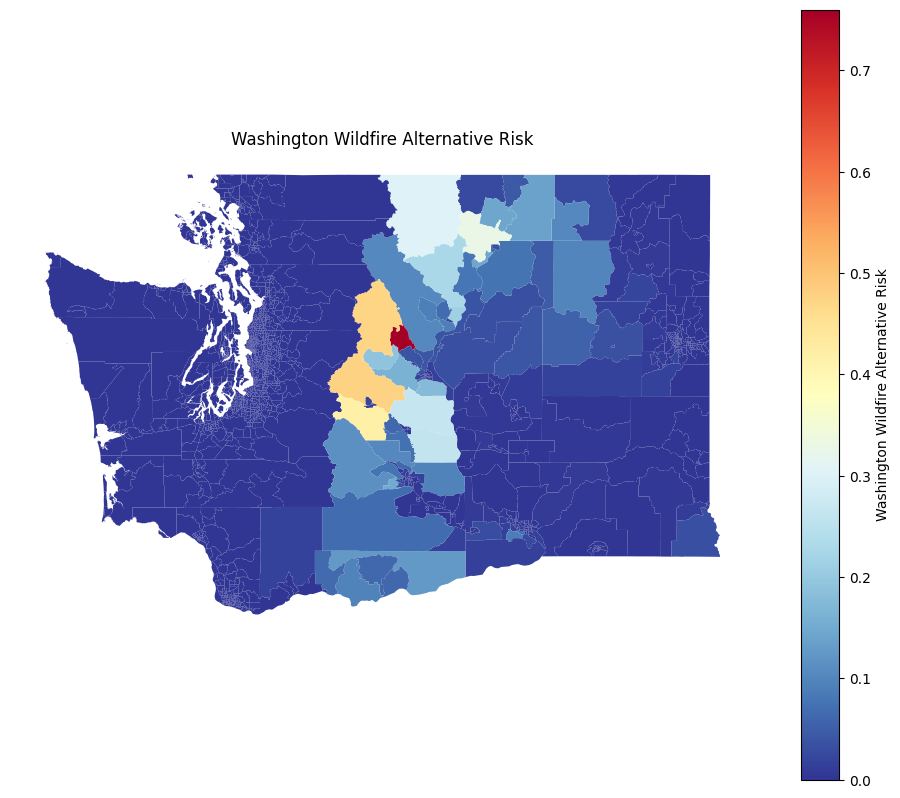

In [58]:
## Washington wildfire alternative risk map 
if "wa_wildfire_alt_risk" in risk_data.columns:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    wa_map.plot(
    column="wa_wildfire_alt_risk",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Washington Wildfire Alternative Risk"}
    )
    ax.set_title("Washington Wildfire Alternative Risk")
    ax.axis("off")
    plt.show()